Ускорение свободного падения: g = 9.8

Массы: m1 = 1.0, m2 = 1.0

Длины: L1 = 1.0, L2 = 1.0

Интервал времени: t0 = 0.0, tf = 30.0

Шаг интегрирования: dt = 0.001

Большие начальные углы : θ1 = 150°, θ2 = −10°, начальные скорости ω1 = ω2 = 0

Малое возмущение для проверки чувствительности: ε = 1e−3 рад

In [3]:
import math
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display

g = 9.8
m1 = 1.0
m2 = 1.0
L1 = 1.0
L2 = 1.0

# временная сетка
t0 = 0.0
tf = 30.0
dt = 0.001

# большие начальные углы для анимации (задание 2)
th1_deg = 150.0
th2_deg = -10.0

# малое возмущение
eps = 1e-3     # рад

# служебное
params = (m1, m2, L1, L2, g)
print("Matplotlib:", matplotlib.__version__)

Matplotlib: 3.10.0



Применяя **уравнения Эйлера–Лагранжа** к координатам,
получаем систему дифференциальных уравнений второго порядка.


y(t)=
\begin{bmatrix}
\theta_1 \\[2pt]
\omega_1 \\[2pt]
\theta_2 \\[2pt]
\omega_2
\end{bmatrix},
 y(t)=
\begin{bmatrix}
\omega_1 \\[2pt]
\alpha_1(\theta_1,\omega_1,\theta_2,\omega_2) \\[2pt]
\omega_2 \\[2pt]
\alpha_2(\theta_1,\omega_1,\theta_2,\omega_2)
\end{bmatrix}.
\]


\[
\begin{aligned}
\text{den}_1 &= (m_1+m_2)L_1 - m_2 L_1 \cos^2\Delta, \\[4pt]
\text{den}_2 &= \frac{L_2}{L_1}\,\text{den}_1.
\end{aligned}
\]

Тогда сами ускорения вычисляются по формулам:

\[
\begin{aligned}
\alpha_1 &=
\frac{
m_2 L_1 \omega_1^2 \sin\Delta\cos\Delta
+ m_2 g \sin\theta_2 \cos\Delta
+ m_2 L_2 \omega_2^2 \sin\Delta
- (m_1+m_2) g \sin\theta_1
}{
\text{den}_1
}, \\[6pt]
\alpha_2 &=
\frac{
 -m_2 L_2 \omega_2^2 \sin\Delta\cos\Delta
 + (m_1+m_2)\left(
 g \sin\theta_1\cos\Delta
 - L_1 \omega_1^2 \sin\Delta
 - g \sin\theta_2
 \right)
}{
\text{den}_2
}.
\end{aligned}
\]


In [17]:
# ЯЧЕЙКА 2 — Уравнения движения и интегратор RK4

def equations_of_motion_double_pendulum(t, y, params):
    """
    y = [th1, w1, th2, w2] -> d/dt y = [w1, a1, w2, a2]
    """
    (m1, m2, L1, L2, g) = params
    th1, w1, th2, w2 = y
    delta = th2 - th1

    den1 = (m1 + m2) * L1 - m2 * L1 * math.cos(delta)**2
    den2 = (L2 / L1) * den1

    a1 = (m2 * L1 * w1**2 * math.sin(delta) * math.cos(delta) +
          m2 * g * math.sin(th2) * math.cos(delta) +
          m2 * L2 * w2**2 * math.sin(delta) -
          (m1 + m2) * g * math.sin(th1)) / den1

    a2 = (-m2 * L2 * w2**2 * math.sin(delta) * math.cos(delta) +
          (m1 + m2) * (g * math.sin(th1) * math.cos(delta) -
                       L1 * w1**2 * math.sin(delta) -
                       g * math.sin(th2))) / den2

    return np.array([w1, a1, w2, a2], dtype=float)


def rk4(f, t0, y0, dt, n_steps, params):
    """Классический RK4 с равномерным шагом."""
    ts = np.empty(n_steps + 1)
    ys = np.empty((n_steps + 1, len(y0)))
    ts[0] = t0
    ys[0] = y0
    t = t0
    y = np.array(y0, dtype=float)

    for i in range(1, n_steps + 1):
        k1 = f(t, y, params)
        k2 = f(t + 0.5 * dt, y + 0.5 * dt * k1, params)
        k3 = f(t + 0.5 * dt, y + 0.5 * dt * k2, params)
        k4 = f(t + dt, y + dt * k3, params)
        y = y + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
        t = t + dt
        ts[i] = t
        ys[i] = y

    return ts, ys


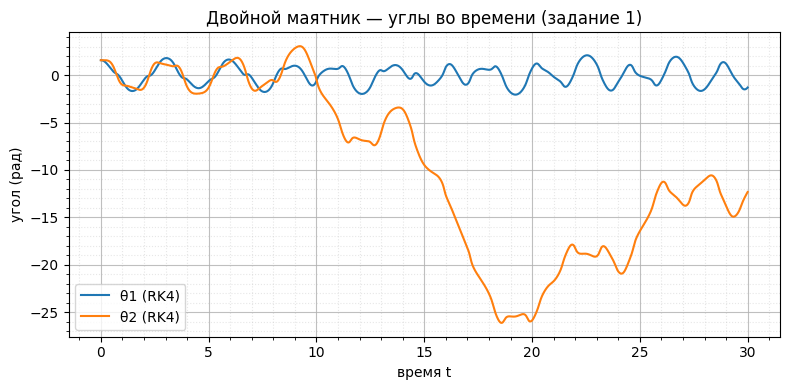

In [6]:
# начальные условия для базового уровня
y0_task1 = np.array([math.pi/2, 0.0, math.pi/2, 0.0], dtype=float)

n_steps = int((tf - t0) / dt)
t_rk4, y_rk4 = rk4(equations_of_motion_double_pendulum, t0, y0_task1, dt, n_steps, params)

plt.figure(figsize=(8,4))
plt.plot(t_rk4, y_rk4[:, 0], label="θ1 (RK4)")
plt.plot(t_rk4, y_rk4[:, 2], label="θ2 (RK4)")
plt.xlabel("время t")
plt.ylabel("угол (рад)")
plt.title("Двойной маятник — углы во времени (задание 1)")
plt.legend()
plt.minorticks_on()
plt.grid(which="major", alpha=0.8)
plt.grid(which="minor", alpha=0.3, linestyle=":")
plt.tight_layout()
plt.show()


- начальные углы: θ₁ = 150°, θ₂ = −10°, ω₁ = ω₂ = 0  

In [7]:
def angles_to_xy(th1, th2, L1, L2):
    x1 = L1 * np.sin(th1);  y1 = -L1 * np.cos(th1)
    x2 = x1 + L2 * np.sin(th2);  y2 = y1 - L2 * np.cos(th2)
    return x1, y1, x2, y2


def save_double_pendulum_gif(t, th1, th2, L1, L2, out_path="double_pendulum.gif",
                             title="Двойной маятник: большие углы", max_frames=1200, fps=30):
    x1, y1, x2, y2 = angles_to_xy(th1, th2, L1, L2)

    fig, ax = plt.subplots()
    ax.set_aspect('equal', 'box')
    R = L1 + L2
    ax.set_xlim(-R - 0.2, R + 0.2)
    ax.set_ylim(-R - 0.2, R + 0.2)
    ax.set_title(title)
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.grid(alpha=0.4)

    line1, = ax.plot([], [], lw=2)
    line2, = ax.plot([], [], lw=2)
    m1dot, = ax.plot([], [], 'o')
    m2dot, = ax.plot([], [], 'o')
    trace, = ax.plot([], [], lw=1, alpha=0.7)

    trail_x, trail_y = [], []

    # прореживание до max_frames
    step = max(1, len(t) // max_frames)
    idxs = np.arange(0, len(t), step)

    def init():
        line1.set_data([], []); line2.set_data([], [])
        m1dot.set_data([], []); m2dot.set_data([], [])
        trace.set_data([], [])
        return line1, line2, m1dot, m2dot, trace

    def update(k):
        i = idxs[k]
        line1.set_data([0, x1[i]], [0, y1[i]])
        line2.set_data([x1[i], x2[i]], [y1[i], y2[i]])
        m1dot.set_data([x1[i]], [y1[i]])
        m2dot.set_data([x2[i]], [y2[i]])
        trail_x.append(x2[i]); trail_y.append(y2[i])
        trace.set_data(trail_x, trail_y)
        return line1, line2, m1dot, m2dot, trace

    ani = FuncAnimation(fig, update,
                        frames=len(idxs),
                        init_func=init,
                        blit=False,
                        interval=20)

    ani.save(out_path, writer=PillowWriter(fps=fps))
    plt.close(fig)
    return out_path


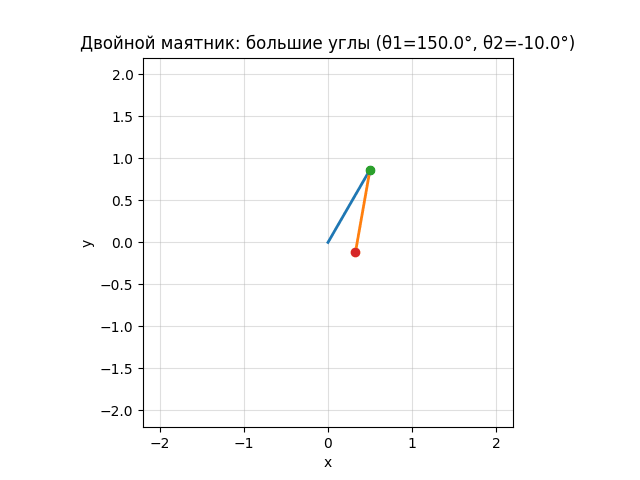

In [8]:
y0_big = np.array([np.deg2rad(th1_deg), 0.0, np.deg2rad(th2_deg), 0.0], dtype=float)

n_steps_anim = int((min(tf, 20.0) - t0) / dt)
t_anim, Y_anim = rk4(equations_of_motion_double_pendulum, t0, y0_big, dt, n_steps_anim, params)

gif_path = save_double_pendulum_gif(
    t_anim, Y_anim[:, 0], Y_anim[:, 2], L1, L2,
    out_path="double_pendulum.gif",
    title=f"Двойной маятник: большие углы (θ1={th1_deg}°, θ2={th2_deg}°)",
    max_frames=1200,
    fps=10
)

display(Image(gif_path)) # отрабатыввет довольно долго (на чистом python гораздо быстрее, чем в jupyter)


1. **Угловое расхождение**


   $$d_{\theta}(t) = \sqrt{(\theta_1 - \theta_1')^2 + (\theta_2 - \theta_2')^2}.$$

2. **Расхождение положений кончика второго маятника**

   $$d_{r}(t) = \sqrt{(x_2 - x_2')^2 + (y_2 - y_2')^2}.$$


In [15]:
def analyze_sensitivity(t, Y_base, Y_pert, L1, L2, eps_pos_floor=1e-12):
    th1, th2 = Y_base[:, 0], Y_base[:, 2]
    th1p, th2p = Y_pert[:, 0], Y_pert[:, 2]

    # 1) угловое расхождение
    dtheta = np.sqrt((th1 - th1p)**2 + (th2 - th2p)**2)

    # 2) расхождение кончиков
    def ang2xy(th1_, th2_):
        x1 = L1 * np.sin(th1_);  y1 = -L1 * np.cos(th1_)
        x2 = x1 + L2 * np.sin(th2_);  y2 = y1 - L2 * np.cos(th2_)
        return x2, y2

    x2, y2   = ang2xy(th1,  th2)
    x2p, y2p = ang2xy(th1p, th2p)
    dr = np.sqrt((x2 - x2p)**2 + (y2 - y2p)**2)
    dr0 = max(dr[0], eps_pos_floor)


    fig, axes = plt.subplots(2, 1, figsize=(9, 9), sharex=True)

    axes[0].plot(t, dtheta)
    axes[0].set_ylabel("dθ(t)")
    axes[0].set_xlabel("t")
    axes[0].set_title("Расхождение по углам")
    axes[0].grid(alpha=0.4)

    axes[1].semilogy(t, dr + eps_pos_floor)
    axes[1].set_ylabel("dr(t)")
    axes[1].set_xlabel("t")
    axes[1].set_title("Расхождение кончиков")
    axes[1].grid(alpha=0.4, which='both')


    plt.tight_layout()
    plt.show()

    # траектории кончика второго маятника
    plt.figure(figsize=(6,6))
    plt.plot(x2,  y2,  label="базовая траеткория")
    plt.plot(x2p, y2p, label="возмущение ε", alpha=0.8)
    plt.gca().set_aspect('equal', 'box')
    plt.title("Траектории кончика второго маятника")
    plt.xlabel("x"); plt.ylabel("y")
    plt.grid(alpha=0.4); plt.legend()
    plt.tight_layout()
    plt.show()


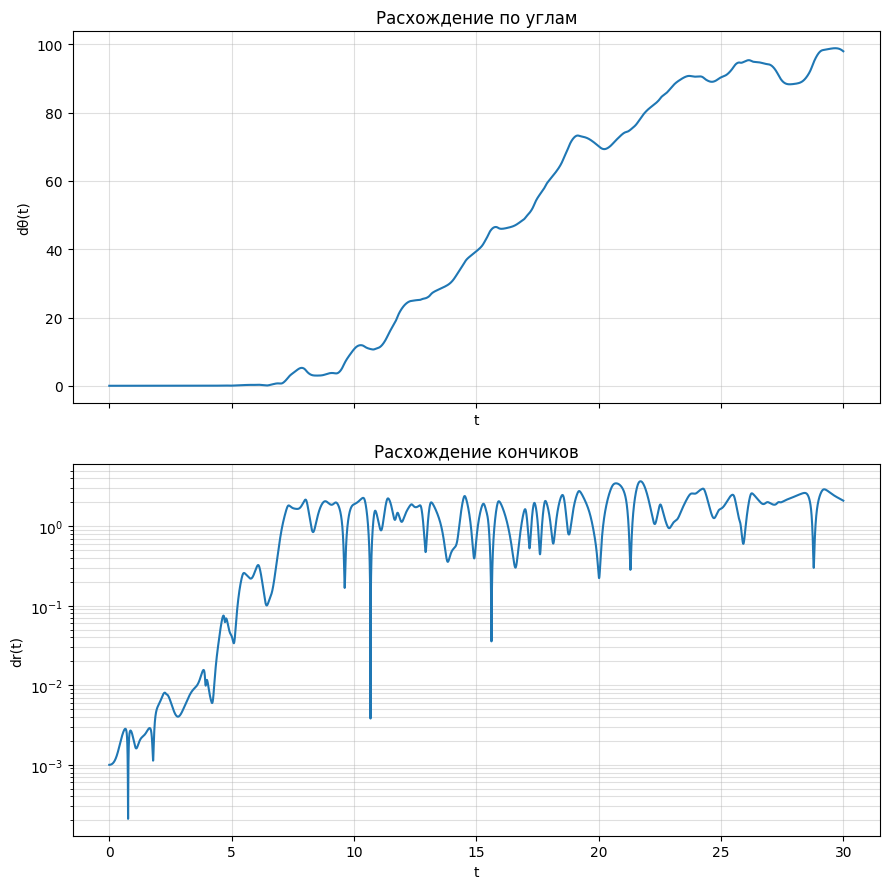

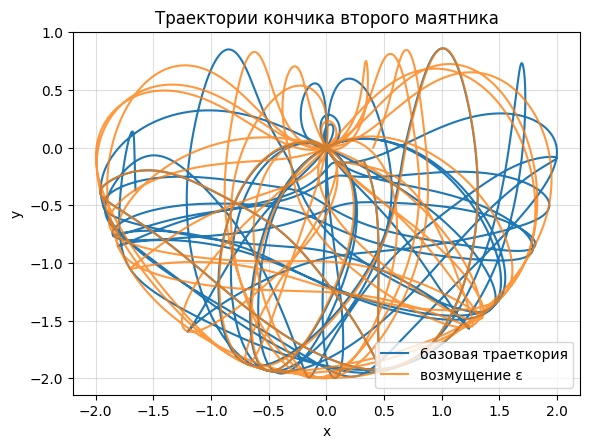

In [16]:
# базовая траектория
y0_big = np.array([np.deg2rad(th1_deg), 0.0, np.deg2rad(th2_deg), 0.0], dtype=float)

# возмущённая траектория
y0_big_pert = y0_big.copy()
y0_big_pert[0] += eps

n_steps_sens = int((tf - t0) / dt)
t_sens, Y_base = rk4(equations_of_motion_double_pendulum, t0, y0_big, dt, n_steps_sens, params)
_,       Y_pert = rk4(equations_of_motion_double_pendulum, t0, y0_big_pert, dt, n_steps_sens, params)

analyze_sensitivity(t_sens, Y_base, Y_pert, L1, L2)
